[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/erickmunoz-univalle/erickmunoz-fisica-computacional-2026ii-univalle/blob/main/Decaimiento_Radioactivo_Python/taller2_colab.ipynb)


# Taller 2 de  Física Computacional
Solución de Taller 1 del taller de físcia computacional.

**Estudiante:** Erick Alexander Muñoz Orozco

**Lenguaje:** Python

**Tema:** Precisión y Decaimiento radiactivo en Python



---



**A. Jugando con la precision en Python**

**1. Complete y depure `suma_seno` (sección 7, "B. Completar el algoritmo") si aún no lo ha hecho.**

In [ ]:
def suma_seno(x, tol=1e-8, max_iter=200):            # Define una función para aproximar sin(x) mediante su serie de Taylor.
    term = x                                         # Inicializa el primer término de la serie: t_0 = x.
    total = x                                        # Inicializa la suma parcial con el primer término.
    n = 0                                            # Inicializa el índice usado para construir los términos siguientes.

    for i in range(max_iter):                        # Repite como máximo max_iter veces para evitar un ciclo infinito.
        n += 1                                       # Incrementa n antes de calcular el siguiente término de la serie.
        term = -term * x**2 / ((2*n)*(2*n+1))        # Relación recursiva para ahorrar tiempo, recursos y riesgo
        total = total + term                         # Añade el nuevo término a la suma parcial.

        if abs(term) < tol * max(1, abs(total)):     # Criterio mixto, para evitar problemas cuando la suma esté cerca de cero
            break                                    # Sale del ciclo cuando el último término ya es suficientemente pequeño.

    return total, i + 1  # Devuelve la aproximación calculada y el número de iteraciones realizadas.

2. Genere la tabla de convergencia (como en la sección 7) para al menos 6 valores de $x$ entre $0$ y $4\pi$, incluyendo el número de iteraciones, la suma y el error relativo frente a `math.sin`.

In [ ]:
import math  # Importa el módulo math para usar la función seno de referencia.

valores = [0.5, 1.5, 2.5, 2.8, 3.2, 4.9] #Lista con valores para la tabla

print(f"{"x":>6} {"imax":>6} {"suma":>16} {"error relativo":>16}")  # Imprime el encabezado de una tabla con columnas alineadas.
for x in valores:  # Recorre varios valores de x para probar el algoritmo.
    approx, iters = suma_seno(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    print(f"{x:6.2f} {iters:6d} {approx:16.10f} {error_relativo:16.2e}")  # Imprime una fila de la tabla con formato numérico.

     x   imax             suma   error relativo
  0.50      4     0.4794255386         2.55e-11
  1.50      7     0.9974949866         2.76e-12
  2.50      9     0.5984721441         7.35e-12
  2.80      9     0.3349881501         1.41e-10
  3.20     10    -0.0583741434         2.71e-10
  4.90     13    -0.9824526126         1.16e-11


**3. Con los datos de la tabla del punto anterior, compare el error relativo de cada caso contra la tolerancia esperada $10^{-8}$: ¿en todos los valores de $x$ que probó el error relativo queda por debajo de esa tolerancia? Si en algún caso no es así, indique para cuáles valores de $x$ ocurre y explique a qué se debe.**

In [ ]:
tol = 1e-8 # Valor de la tolerancia

print(f"Tolerancia usada: {tol:.0e}\n")  # Imprime la tolerancia al inicio

print(f"{"x":>6} {"exacto":>16} {"suma":>16} {"error relativo":>16} {"¿cumple?":>10}") # Imprime el encabezado de una tabla con columnas alineadas.

for x in valores: # Recorre varios valores de x para probar el algoritmo.
    approx, iters = suma_seno(x)  # Calcula la aproximación de sin(x) y guarda también las iteraciones utilizadas.
    exacto = math.sin(x)  # Calcula el valor de referencia usando la implementación de math.sin.
    error_relativo = abs(approx - exacto) / abs(exacto)  # Calcula el error relativo de la aproximación respecto al valor de referencia.
    cumple = "SÍ" if error_relativo < tol else "NO"
    print(f"{x:6.2f} {exacto:16.10f} {approx:16.10f} {error_relativo:16.2e} {cumple:>10}")


Tolerancia usada: 1e-08

     x           exacto             suma   error relativo   ¿cumple?
  0.50     0.4794255386     0.4794255386         2.55e-11         SÍ
  1.50     0.9974949866     0.9974949866         2.76e-12         SÍ
  2.50     0.5984721441     0.5984721441         7.35e-12         SÍ
  2.80     0.3349881502     0.3349881501         1.41e-10         SÍ
  3.20    -0.0583741434    -0.0583741434         2.71e-10         SÍ
  4.90    -0.9824526126    -0.9824526126         1.16e-11         SÍ


**4. Repita el experimento de la sección 7 para $x$ grande (por ejemplo, $x=100$) sin la reducción de periodicidad, y explique en una o dos frases qué está pasando numéricamente.**

In [ ]:
x = 100 # Valor grande para x, x=100

approx, iters = suma_seno(x)  # Usando la serie directamente, sin reducción
exacto = math.sin(x) # Calcula el valor de referencia usando la implementación de math.sin.
error_relativo = abs(approx - exacto) / abs(exacto) # Calcula el error relativo de la aproximación respecto al valor de referencia.

print(f"{'x':>6} {'exacto':>16} {'aproximado':>12} {'iter':>6} {'error relativo':>16}") # Imprime el encabezado de una tabla con columnas alineadas.
print(f"{x:6.2f} {exacto:16.10f} {approx:12.2e} {iters:6d} {error_relativo:16.2e}") # Imprime una fila de la tabla con formato numérico.

     x           exacto   aproximado   iter   error relativo
100.00    -0.5063656411    -8.26e+25    111         1.63e+26


**Rta:**  
En el criterio de parada, el producto `tol * |total|` se vuelve siendo gigantesco, el algoritmo se detiene, los valores no alcanzan a cancelarse correctamente, de modo que el resultado final es numéricamente inestable para valores grandes de \(x\).


**5. Compare su implementación recursiva con una versión "ingenua" que calcule cada término desde cero usando `math.factorial` y `x**potencia` — ¿en qué valores de $x$ empieza a notarse la diferencia de desempeño o de precisión?**

In [ ]:
import time # Lo usaremos para registrar el tiempo del cálculo de cada x según la función que usemos

# Implementación ingenua: calcula cada término desde cero usando factorial y potencias
def suma_seno_ingenua(x, tol=1e-8, max_iter=200):
    total = 0.0
    for n in range(max_iter):
        # Cada término de la serie de Taylor: (-1)^n * x^(2n+1) / (2n+1)!
        term = ((-1)**n) * (x**(2*n+1)) / math.factorial(2*n+1)
        total += term
        # Criterio mixto de parada: el término debe ser pequeño relativo al total
        if abs(term) < tol * max(1, abs(total)):
            return total, n+1
    return total, max_iter  # Si no converge, retorna con el máximo de iteraciones

# Implementación recursiva: cada término se obtiene a partir del anterior
def suma_seno_recursiva(x, tol=1e-8, max_iter=200):
    term = x       # Primer término de la serie
    total = x      # Inicializa la suma con el primer término
    n = 0
    for i in range(max_iter):
        n += 1
        # Relación recursiva: evita recalcular factoriales y potencias
        term = -term * x**2 / ((2*n)*(2*n+1))
        total += term
        # Criterio mixto de parada
        if abs(term) < tol * max(1, abs(total)):
            return total, i+1
    return total, max_iter

# Valores de prueba: pequeños, medianos y grandes
valores = [0.5, 1.5, 5.0, 10.0, 20.0, 50.0, 66.0]
tol = 1e-8

# Imprime el encabezado de una tabla con columnas alineadas.
print(f"{'x':>6} {'exacto':>12} {'recursiva':>26} {'ERP_R':>12} {'ingenua':>26} {'ERP_I':>12} {'t_rec':>10} {'t_ing':>10}")

# Bucle principal: compara recursiva vs ingenua en cada valor de x
for x in valores:
    exacto = math.sin(x)  # Valor de referencia con math.sin

    # Tiempo y resultado de la versión recursiva
    t0 = time.time()
    rec, itR = suma_seno_recursiva(x)
    t1 = time.time()

    # Tiempo y resultado de la versión ingenua
    ing, itI = suma_seno_ingenua(x)
    t2 = time.time()

    # Error relativo porcentual (ERP) respecto a math.sin
    ERP_R = abs(rec - exacto) / abs(exacto)
    ERP_I = abs(ing - exacto) / abs(exacto)

    # Imprime resultados en formato tabular
    print(f"{x:6.2f} {exacto:12.8f} {rec:26.8f} {ERP_R:12.2e} {ing:26.8f} {ERP_I:12.2e} {(t1-t0):10.6f} {(t2-t1):10.6f}")


     x       exacto                  recursiva        ERP_R                    ingenua        ERP_I      t_rec      t_ing
  0.50   0.47942554                 0.47942554     2.55e-11                 0.47942554     2.55e-11   0.000027   0.000014
  1.50   0.99749499                 0.99749499     2.76e-12                 0.99749499     2.76e-12   0.000010   0.000013
  5.00  -0.95892427                -0.95892427     2.14e-11                -0.95892427     2.14e-11   0.000014   0.000024
 10.00  -0.54402111                -0.54402111     2.89e-10                -0.54402111     2.90e-10   0.000020   0.000034
 20.00   0.91294525                 0.91294526     5.34e-09                 0.91294525     3.20e-09   0.000028   0.000064
 50.00  -0.26237485            -15566.59593406     5.93e+04             27473.52408451     1.05e+05   0.000052   0.001327
 66.00  -0.02655115     -106912239191.37756348     4.03e+12     -248302256778.60156250     9.35e+12   0.000062   0.000245


**Rta:**  
Tanto la versión recursiva como la ingenua son susceptibles a errores grandes cuando se acumulan sumatorias con términos gigantes, y en el límite de iteraciones no alcanzan a cancelarse adecuadamente.  
Si se intentara aumentar el número de iteraciones, la suma seguiría creciendo hasta valores descomunales, con riesgo de *overflow*, especialmente cuando el argumento es muy grande.  

En este contexto, ya se observa que para valores grandes:  
- La versión ingenua presenta errores relativos más altos, porque los factoriales y potencias intermedias generan pérdidas de precisión.  
- Además, tarda más en calcular el seno, ya que cada término requiere recomputar factoriales y potencias desde cero.


**6. Definiendo suma_seno_reducida(x) para la verificación en PASS - FAIL.**

A continuación solo definiremos la función suma_seno_reducida(x), para usarla para la verificación **PASS - FAIL** en el punto **C**

In [ ]:
def suma_seno_reducida(x, tol=1e-8, max_iter=200):  # Define una versión que primero reduce el argumento antes de evaluar la serie.
    x_reducido = math.remainder(x, 2 * math.pi)  # Reduce x módulo 2*pi a un intervalo centrado aproximadamente en [-pi, pi].
    return suma_seno(x_reducido, tol, max_iter)  # Evalúa la serie usando el argumento reducido y devuelve el resultado.



---



**B. Decaimiento radiactivo con Python (Entregar Reporte)**

**1. Calcule la constante de decaimiento $\lambda$.**

In [ ]:
import math
# Calculemos
t_media = 5  # Vida media en años
Lambda = math.log(2) / t_media  # Constante de decaimiento
print("Constante de decaimiento λ =", Lambda)

Constante de decaimiento λ = 0.13862943611198905


**2. Utilice `numpy.linspace()` para crear un arreglo de tiempos entre 0 y 30 años. Utilice un número suficiente de puntos para observar claramente la evolución de la muestra.**

**3. Calcule $N(t)$ para todos los valores del arreglo de tiempos utilizando las operaciones vectorizadas de NumPy. Sin usar For**

**4. Utilice `matplotlib` para representar gráficamente $N(t)$ en función del tiempo. La gráfica debe incluir:**

   - **título**;
   - **nombre de los ejes**;
   - **unidades**;
   - **una cuadrícula que facilite la lectura de los resultados.**

**5. Identifique sobre la gráfica los tiempos correspondientes a una, dos y tres vidas medias. Observe qué fracción de la muestra permanece después de cada una de ellas.**

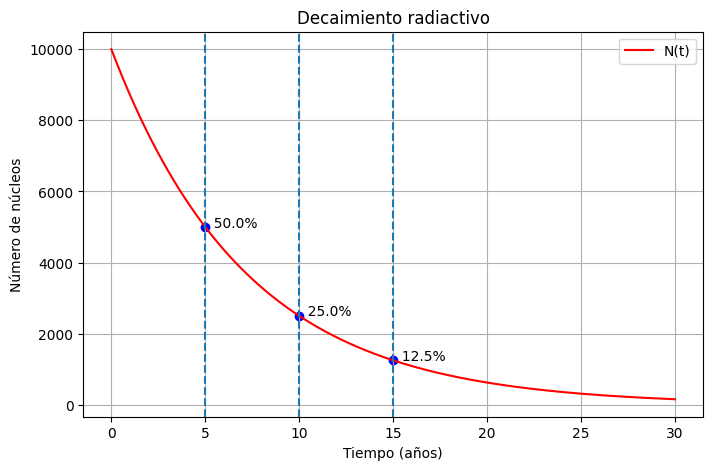

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros iniciales
N0 = 10000          # número inicial de núcleos
t_medio = 5          # vida media en años
Lambda = np.log(2) / t_medio   # constante de decaimiento

# 2. Arreglo de tiempos entre 0 y 30 años
# Usamos 300 puntos para ver claramente la evolución
t = np.linspace(0, 30, 300)

# 3. Cálculo vectorizado de N(t) sin usar for
N = N0 * np.exp(-Lambda * t)

# 4. Gráfica con matplotlib
plt.figure(figsize=(8,5))
plt.plot(t, N, 'r-', label="N(t)")
# Configuración de la gráfica
plt.title("Decaimiento radiactivo")
plt.xlabel("Tiempo (años)")
plt.ylabel("Número de núcleos")
plt.grid(True)
plt.legend()

#5. Una, dos, tres vidas medias.
vidas_medias = [] # Lista a indexar con tiempo, nucleos y fracción de las vidas medias
# Ciclo for para Indexar la lista vidas_medias con los datos
for n in [1, 2, 3]:
    tiempo = n * t_medio # Tiempo de cada vida media
    nucleos = N0 * np.exp(-Lambda * tiempo) # Nucleos de cada vida media
    fraccion = nucleos / N0 # Fracción que permanece después de cada vida media
    vidas_medias.append((tiempo, nucleos, fraccion)) # Indexamos los datos a la lista
# Ciclo for para mostrar en la gráfica los datos
for (tiempo, nucleos, fraccion) in vidas_medias: # Los datos se muestran por (tiempo, nucleos, fraccion)
    plt.axvline(x=tiempo, linestyle="--") # Graficamos la linea vertical en cada vida media
    plt.scatter(tiempo, nucleos, color="blue") # Graficamos los puntos de cada vida media

    plt.text(tiempo, nucleos, f"  {fraccion:.1%}")

plt.show()


**Rta:**  
Para 1 vida media permanece el 50% de la muestra.

Para 2 vidas medias permanece el 25% de la muestra.

Para 3 vidas medias permanece el 12.5% de la muestra.


**6. Determine aproximadamente el tiempo en el cual permanece:**

   - **el **50 %** de la muestra inicial;**
   - **el **25 %** de la muestra inicial;**
   - **el **10 %** de la muestra inicial.**

In [ ]:
# El tiempo de cada vida media será múltiplo de 1 vida media
t_medio = 5.0 # Tiempo de 1 vida media en años
t2_medio = 2.0 * t_medio # Tiempo de 2 vidas medias en años
t3_medio = 3.0 * t_medio # Tiempo de 3 vidas medias en años

print(f"Tiempo de 1 vida media: {t_medio:.1f} años")
print(f"Tiempo de 2 vidas medias: {t2_medio:.1f} años")
print(f"Tiempo de 3 vidas medias: {t3_medio:.1f} años")

Tiempo de 1 vida media: 5.0 años
Tiempo de 2 vidas medias: 10.0 años
Tiempo de 3 vidas medias: 15.0 años




---



**C. Celda de verificación (PASS/FAIL)**

**1. Verificación parte A**

In [ ]:
# --- Verificación Parte A: suma_seno_reducida ---
casos_a = [                                        # Lista de (x, valor_esperado, tolerancia) para probar la Parte A.
    (0.5, math.sin(0.5), 1e-8),                    # Caso dentro del rango normal de convergencia rápida.
    (100.0, math.sin(100.0), 1e-6),                # Caso con x grande: solo debe pasar si se usó reducción de argumento.
    (-237.0, math.sin(-237.0), 1e-6),              # Caso con x grande y negativo.
]

for x, esperado, tol in casos_a:                   # Recorre cada caso de prueba uno por uno.
    obtenido, itloka = suma_seno_reducida(x)             # Calcula sin(x) con la función que el estudiante debe haber completado.
    ok = abs(obtenido - esperado) < tol             # Compara contra el valor de referencia dentro de la tolerancia.
    estado = "PASS" if ok else "FAIL"               # Traduce el resultado booleano a texto legible.
    print(f"{estado}  x={x:>8.1f}   obtenido={obtenido: .10f}   esperado={esperado: .10f}")  # Imprime el veredicto de este caso.

PASS  x=     0.5   obtenido= 0.4794255386   esperado= 0.4794255386
PASS  x=   100.0   obtenido=-0.5063656411   esperado=-0.5063656411
PASS  x=  -237.0   obtenido= 0.9819578697   esperado= 0.9819578698


**2. Verificación parte B.**

In [ ]:
# --- Parte B: complete N_decaimiento y luego corra la verificación ---
import numpy as np
def N_decaimiento(t, N0=10000, t_half=5.0):        # Complete esta función según N(t) = N0 * exp(-lambda*t).
    N = N0 * np.exp(-np.log(2) / t_half * t)
    return N

casos_b = [                                        # Lista de (t, fracción_esperada): fracción de N0 que debería quedar en cada instante.
    (0.0, 1.00),                                   # En t=0 debe quedar el 100% de la muestra.
    (5.0, 0.50),                                   # En t = t_1/2 (una vida media) debe quedar el 50%.
    (10.0, 0.25),                                  # En t = 2*t_1/2 (dos vidas medias) debe quedar el 25%.
]

for t, fraccion_esperada in casos_b:               # Recorre cada caso de prueba.
    try:                                           # Evita que un NotImplementedError detenga toda la celda de verificación.
        obtenido = N_decaimiento(t) / 10000        # Calcula qué fracción de N0 queda en el instante t.
        ok = abs(obtenido - fraccion_esperada) < 1e-3  # Compara contra la fracción esperada con tolerancia razonable.
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:               # Si aún no se ha completado la función, lo informa sin detener la celda.
        print(f"FAIL  t={t:>5.1f} años   ({e})")

PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250




---

